In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generate a synthetic e-commerce / tech product dataset
n_rows = 500
dates = pd.date_range(start="2026-01-01", periods=n_rows, freq="D")
categories = ['Electronics', 'Accessories', 'Software', 'Hardware']

data = {
    'Date': np.random.choice(dates, n_rows),
    'Category': np.random.choice(categories, n_rows, p=[0.3, 0.4, 0.2, 0.1]),
    'Units_Sold': np.random.randint(1, 50, n_rows),
    'Unit_Price': np.random.uniform(10.0, 500.0, n_rows).round(2),
    'Customer_Rating': np.random.choice([3.0, 3.5, 4.0, 4.5, 5.0], n_rows)
}

df = pd.DataFrame(data)
df['Total_Revenue'] = (df['Units_Sold'] * df['Unit_Price']).round(2)

# Display the first 5 rows
print("--- DATASET PREVIEW ---")
display(df.head())

--- DATASET PREVIEW ---


,Date,Category,Units_Sold,Unit_Price,Customer_Rating,Total_Revenue
0,2026-04-13,Electronics,37,495.67,5.0,18339.79
1,2027-03-12,Accessories,27,123.52,3.0,3335.04
2,2026-12-15,Software,33,471.94,3.0,15574.02
3,2026-09-28,Software,4,328.33,4.0,1313.32
4,2026-04-17,Accessories,22,307.79,4.5,6771.38


In [2]:
print("--- DATASET INFO ---")
print(df.info())

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

print("\n--- MISSING VALUES CHECK ---")
print(df.isnull().sum())

--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             500 non-null    datetime64[us]
 1   Category         500 non-null    str           
 2   Units_Sold       500 non-null    int32         
 3   Unit_Price       500 non-null    float64       
 4   Customer_Rating  500 non-null    float64       
 5   Total_Revenue    500 non-null    float64       
dtypes: datetime64[us](1), float64(3), int32(1), str(1)
memory usage: 21.6 KB
None

--- STATISTICAL SUMMARY ---


,Date,Units_Sold,Unit_Price,Customer_Rating,Total_Revenue
count,500,500.000000,500.000000,500.000000,500.000000
mean,2026-09-10 02:55:40.800000,25.886000,259.167020,4.051000,6784.993880
min,2026-01-02 00:00:00,1.000000,12.420000,3.000000,46.010000
25%,2026-05-14 18:00:00,14.000000,128.050000,3.500000,2168.770000
50%,2026-09-09 00:00:00,26.000000,267.635000,4.000000,5280.580000
75%,2027-01-09 06:00:00,38.000000,379.507500,4.500000,10519.610000
max,2027-05-15 00:00:00,49.000000,499.710000,5.000000,23320.080000
std,NaN,14.023206,142.667667,0.712681,5609.177765



--- MISSING VALUES CHECK ---
Date               0
Category           0
Units_Sold         0
Unit_Price         0
Customer_Rating    0
Total_Revenue      0
dtype: int64


In [3]:
# Aggregate total revenue, average revenue, and total units sold per category
category_summary = df.groupby('Category').agg({
    'Total_Revenue': 'sum',
    'Units_Sold': 'sum',
    'Customer_Rating': 'mean'
}).rename(columns={
    'Total_Revenue': 'Sum_Revenue', 
    'Customer_Rating': 'Avg_Rating'
}).sort_values(by='Sum_Revenue', ascending=False)

print("--- PERFORMANCE SUMMARY BY CATEGORY ---")
display(category_summary.round(2))

--- PERFORMANCE SUMMARY BY CATEGORY ---


,Sum_Revenue,Units_Sold,Avg_Rating
Category,,,
Accessories,1453711.32,5139,4.07
Electronics,934306.52,3789,4.09
Software,669634.00,2707,4.03
Hardware,334845.10,1308,3.90


In [4]:
# Use NumPy arrays to calculate custom vectorized metrics
revenues = df['Total_Revenue'].to_numpy()

# Calculate high-value threshold using 75th percentile (NumPy)
high_value_threshold = np.percentile(revenues, 75)
high_value_transactions = df[revenues > high_value_threshold]

print(f"High-Value Revenue Threshold (75th Percentile): ${high_value_threshold:.2f}")
print(f"Total High-Value Transactions: {len(high_value_transactions)}")

print("\n--- SAMPLE HIGH-VALUE TRANSACTIONS ---")
display(high_value_transactions.head())

High-Value Revenue Threshold (75th Percentile): $10519.61
Total High-Value Transactions: 125

--- SAMPLE HIGH-VALUE TRANSACTIONS ---


,Date,Category,Units_Sold,Unit_Price,Customer_Rating,Total_Revenue
0,2026-04-13,Electronics,37,495.67,5.0,18339.79
2,2026-12-15,Software,33,471.94,3.0,15574.02
10,2027-04-12,Software,38,392.00,4.5,14896.00
13,2027-04-04,Accessories,47,484.86,4.5,22788.42
14,2026-03-29,Software,36,443.06,4.0,15950.16


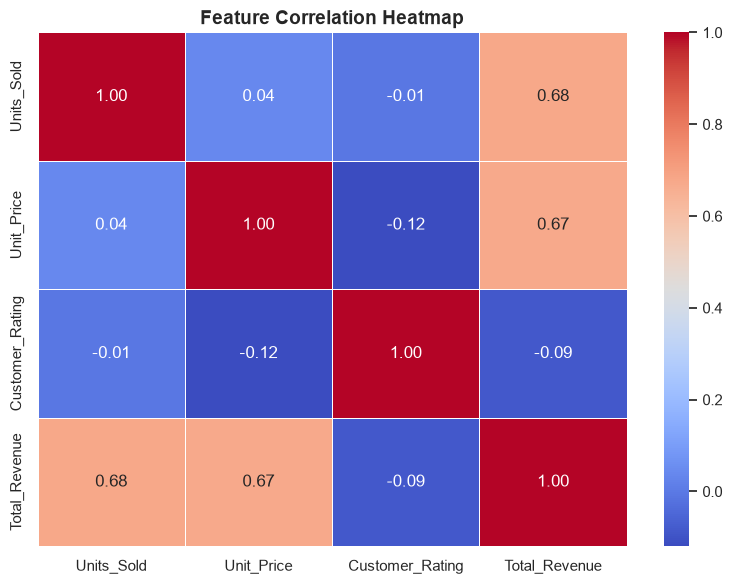

In [5]:
plt.figure(figsize=(8, 6))
numeric_df = df[['Units_Sold', 'Unit_Price', 'Customer_Rating', 'Total_Revenue']]
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()